In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df =pd.read_csv("/content/drive/MyDrive/skin-disease-detection-cnn/data/HAM10000_metadata")
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   dataset       10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0
dataset,0


In [6]:
df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


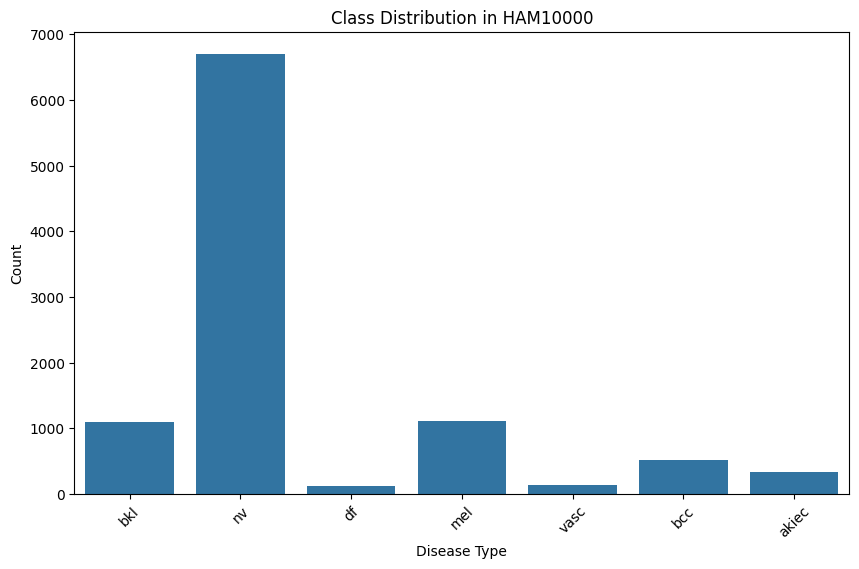

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(x='dx', data=df)
plt.title("Class Distribution in HAM10000")
plt.xlabel("Disease Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [8]:
df['dx'].value_counts(normalize=True) * 100

,proportion
dx,
nv,66.949576
mel,11.113330
bkl,10.973540
bcc,5.132302
akiec,3.265102
vasc,1.417873
df,1.148278


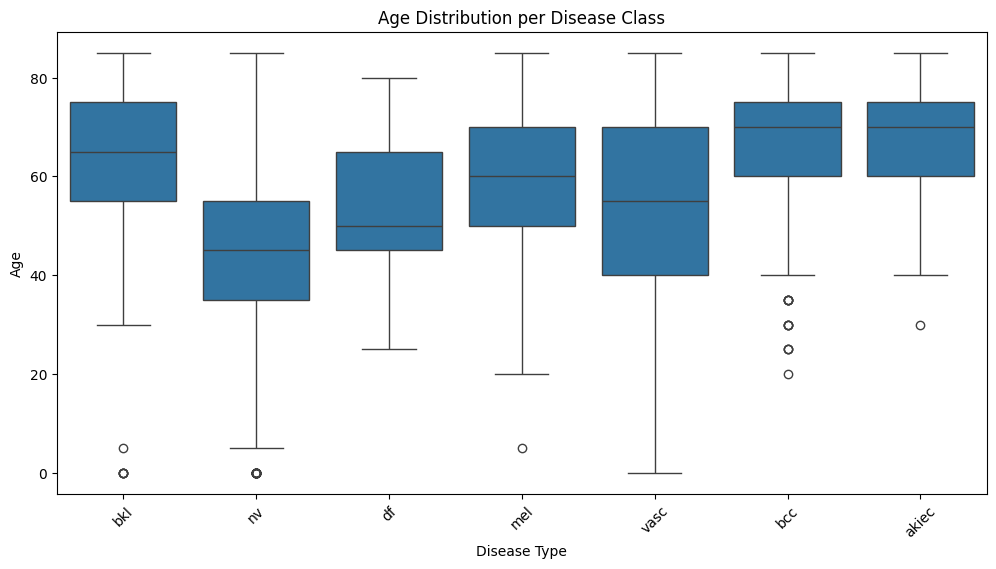

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(x='dx', y='age', data=df)

plt.title("Age Distribution per Disease Class")
plt.xlabel("Disease Type")
plt.ylabel("Age")

plt.xticks(rotation=45)
plt.show()

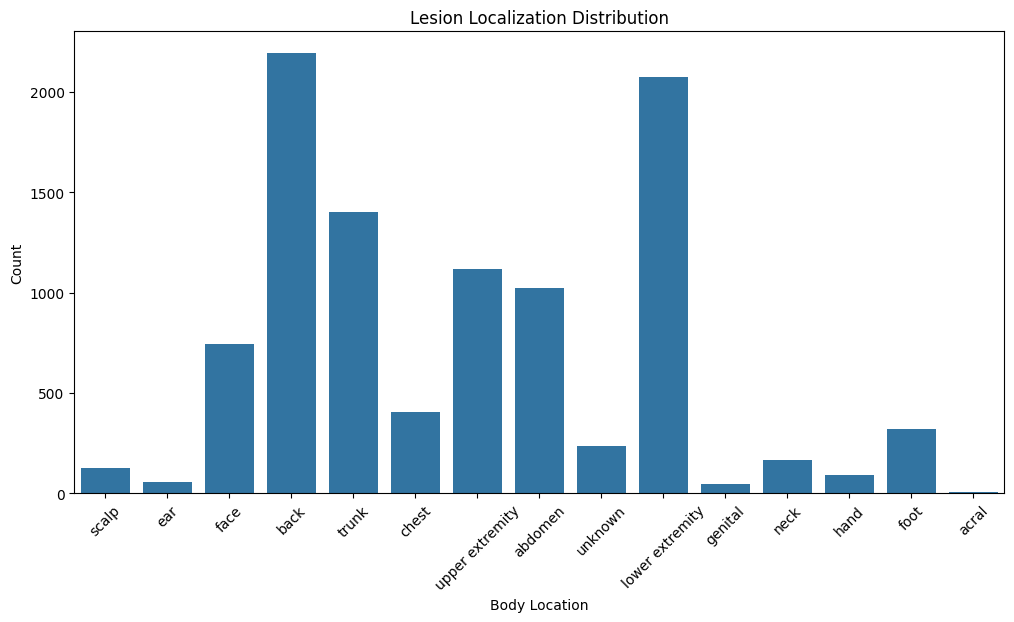

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(x='localization', data=df)

plt.title("Lesion Localization Distribution")
plt.xlabel("Body Location")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

## EDA Summary

- **Total Images:** 10,015 skin lesion images across 7 disease classes
- **Class Distribution:** Severely imbalanced — `nv` (Melanocytic Nevi) dominates
  with 6,705 images (66.9%), while `df` (Dermatofibroma) has only 115 images (1.1%)
- **Missing Values:** 57 missing values found in `age` column only —
  all other columns are complete
- **Lesion Location:** `back` and `lower extremity` are the most common
  lesion sites, consistent with sun-exposed areas
- **Imbalance Strategy:** Class weights will be applied during model training
  to prevent bias towards dominant `nv` class and ensure minority classes
  like `mel` (Melanoma) are correctly identified